### Create AnnData object for GSE145866 — Lgr5-H2 mouse intestinal scRNA-seq

- **Developed by:** Anna Maguza
- **Affiliation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 7 May 2026
- **Last modified date:** 7 May 2026

Single-sample 10x Chromium dataset with two matrices deposited (raw and Cell Ranger-filtered). This notebook uses the filtered matrix (`...2.2.filtered_gene_bc_matrices_*`).

GEO sample name `Lgr5-H2` indicates the Lgr5-EGFP-high sort gate, so all cells are FACS-sorted Lgr5⁺ ISCs (`lgr5_status = 'LGR5+'`, `lgr5_label_raw = 'Lgr5-EGFP-high'`).

⚠️ The science doc (`GSE_datasets_Lgr5_intestinal_stem_cells.md` §3) flags this study as unverified — confirm the publication and 10x chemistry version on GEO before relying on this AnnData for biology. The file structure is unambiguously 10x. See `LGR5_data_folder_inventory.md` for format details.

### Import packages

In [1]:
import os
from datetime import datetime

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sci
from scipy.io import mmread

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
def X_is_raw(adata):
    return np.array_equal(adata.X.sum(axis=0).astype(int), adata.X.sum(axis=0))

### Load 10x trio (filtered)

In [3]:
DATA_DIR = '/Users/am336941/PhD/data/LGR5_analysis_data/GSE145866/GSE145866_RAW'
PREFIX   = 'GSM4338176_Lgr5-H2_2.2.filtered_gene_bc_matrices_'

barcodes = pd.read_csv(os.path.join(DATA_DIR, f'{PREFIX}barcodes.tsv.gz'), sep='\t', header=None, names=['cell_barcode'])
genes    = pd.read_csv(os.path.join(DATA_DIR, f'{PREFIX}genes.tsv.gz'),    sep='\t', header=None, names=['gene_id', 'gene_name'])
matrix   = sci.sparse.csr_matrix(mmread(os.path.join(DATA_DIR, f'{PREFIX}matrix.mtx.gz'))).T

print('cells:', len(barcodes), '| genes:', len(genes), '| matrix:', matrix.shape)

cells: 4815 | genes: 27998 | matrix: (4815, 27998)


In [4]:
obs = barcodes.copy()
obs['cell_id'] = obs['cell_barcode'].astype(str) + '_Lgr5-H2'
obs['sample']          = 'Lgr5-H2'
obs['lgr5_status']     = 'LGR5+'
obs['lgr5_label_raw']  = 'Lgr5-EGFP-high'
obs['condition']       = 'Lgr5-EGFP-high'
obs['cell_type']       = 'Lgr5+ ISC'
obs['GSE']             = 'GSE145866'
obs['organism']        = 'mus musculus'
obs['tissue']          = 'small intestine'
obs['technology']      = '10x Chromium'
obs['assay_modality']  = 'single-cell'
obs = obs.set_index('cell_id')

var = genes.set_index('gene_name')
var.index.name = None

adata = ad.AnnData(X=matrix, obs=obs, var=var)
adata.var_names_make_unique()
for col in ['sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'GSE', 'organism', 'tissue', 'technology', 'assay_modality']:
    adata.obs[col] = adata.obs[col].astype('category')
adata

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 4815 × 27998
    obs: 'cell_barcode', 'sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'GSE', 'organism', 'tissue', 'technology', 'assay_modality'
    var: 'gene_id'

In [5]:
X_is_raw(adata)

True

### QC metrics (mitochondrial + ribosomal)

In [6]:
adata.var['mt']   = adata.var_names.str.startswith('mt-')
adata.var['ribo'] = adata.var_names.str.match(r'^Rp[sl]')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], inplace=True, percent_top=None, log1p=False)
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo']].describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,4815.000000,4815.000000,4815.000000,4815.000000
mean,3508.461890,16817.819107,5.173921,27.017973
std,886.653429,8113.335444,4.042944,6.767076
min,815.000000,4499.000000,0.233903,1.450722
25%,2876.500000,11211.500000,3.605815,23.116068
50%,3458.000000,15192.000000,4.280861,27.285809
75%,4116.000000,20800.500000,5.176405,31.990624
max,6586.000000,90121.000000,50.165344,44.732138


### Sanity check — Lgr5 / Olfm4 / Ascl2 expression

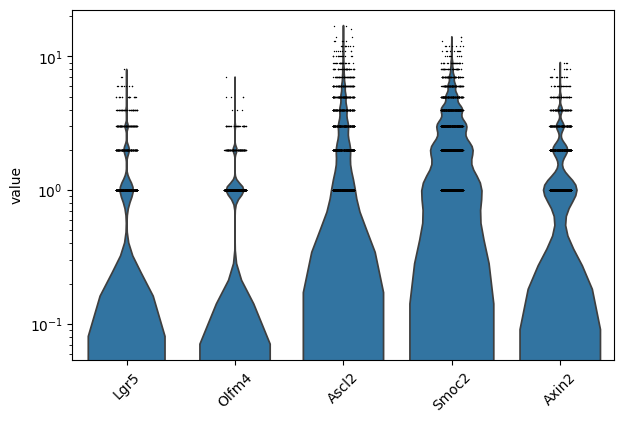

In [7]:
isc_markers = [g for g in ['Lgr5', 'Olfm4', 'Ascl2', 'Smoc2', 'Axin2'] if g in adata.var_names]
if isc_markers:
    sc.pl.violin(adata, isc_markers, rotation=45, log=True)

### Record provenance and save

In [8]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
adata.uns['GSE'] = 'GSE145866'
adata.uns['publication'] = 'GSE145866 (Lgr5-H2) — publication unverified per GSE_datasets_Lgr5_intestinal_stem_cells.md §3; confirm on GEO landing page'
adata.uns['genome_reference'] = 'mm-reference (per GEO upload — exact version not declared in filenames)'
adata.uns['source_files'] = sorted(f for f in os.listdir(DATA_DIR) if f.startswith(PREFIX))
adata.uns['processing_history'] = {
    timestamp: 'AnnData created from GSE145866 Cell Ranger-filtered 10x mtx (single sample Lgr5-H2); lgr5_status=LGR5+ assigned uniformly per Lgr5-EGFP-high sort gate; QC metrics computed; no filtering applied. | note: Raw matrix (...2.1.raw_gene_bc_matrices_*) is also present in the source folder but not used here.',
}

out_dir = 'data/LGR5_analysis'
os.makedirs(out_dir, exist_ok=True)
out_path = f'{out_dir}/gut_mm_GSE145866_AM_{timestamp}_raw.h5ad'
adata.write_h5ad(out_path)
print(out_path, adata.shape)

data/LGR5_analysis/gut_mm_GSE145866_AM_07052026_233747_raw.h5ad (4815, 27998)
